# Integration

In [2]:
!pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.6 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.44.2
    Uninstalling transformers-4.44.2:
      Successfully uninstalled transformers-4.44.2


In [3]:
import torch
import torch.nn as nn
from torchvision import models
import keras
import numpy as np
import tensorflow as tf
from transformers import BlipProcessor, BlipForQuestionAnswering, AutoTokenizer, AutoModelForQuestionAnswering
from PIL import Image
import io
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from matplotlib import pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/model_ilab/

/content/drive/MyDrive/model_ilab


In [15]:
# BLIP model for descriptive answers
model_save_path_blip = "./blip_finetuned_model"  # Adjust this to your BLIP model path
model_blip = BlipForQuestionAnswering.from_pretrained(model_save_path_blip).to(torch.device("cuda"))
processor_blip = BlipProcessor.from_pretrained(model_save_path_blip)

In [16]:
class RadiologyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0]  # Image file path
        label = self.dataframe.iloc[idx, 1]     # 0 or 1 (is_radiology)

        # Load image
        image = Image.open(img_name).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the same ResNet18 model as before
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # Binary classification (1 output)

# Load the trained weights
model.load_state_dict(torch.load('/content/drive/MyDrive/models/radiology_classifier.pth', map_location=device))
model = model.to(device)

# Set the model to evaluation mode
model.eval()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-17-aae007938340>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
from PIL import Image
import torchvision.transforms as transforms

# Define the same image transformation as during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
])

# Function to load and preprocess the image
def preprocess_image(image_path):
    image = Image.open(image_path).convert('RGB')  # Open image and convert to RGB
    image = transform(image)  # Apply transformations
    image = image.unsqueeze(0)  # Add batch dimension (for a single image)
    return image

In [19]:
# Function to check if the image is a radiology image using LLAMA
def is_radiology_image(img_name):
    image = preprocess_image(img_name)

    # Predict on the preprocessed image
    with torch.no_grad():
        image = image.to(device)
        output = model(image)
        prediction = torch.sigmoid(output).item()  # Sigmoid to get the probability


    if prediction >= 0.5:
        return True
    else:
        return False

In [20]:
# Function to generate an answer based on the type of question
def generate_answer(image, question):
    # Check if the image is a radiology image
    if not is_radiology_image(image):
        return "The provided image is not a radiology image."

    # Process the question with BLIP for a descriptive answer
    image = Image.open(image)
    inputs = processor_blip(image, question, return_tensors="pt").to("cuda").to(model_blip.device)
    outputs = model_blip.generate(pixel_values=inputs['pixel_values'],
                          input_ids=inputs['input_ids'])

    # Decode the predicted answer
    answer = processor_blip.decode(outputs[0], skip_special_tokens=True)
    return answer

Saving eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium.jpeg to eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium (2).jpeg


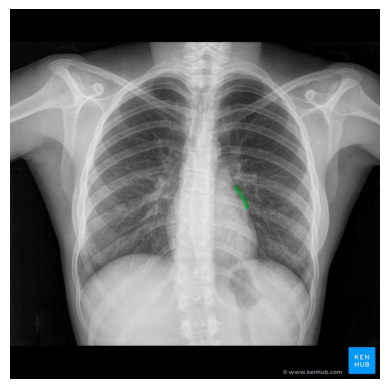

Please enter your question: what is this?


/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1375: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Generated Answer: chest
Please enter your question: is there problem in chest?
Generated Answer: yes
Please enter your question: what is the problem in chest?
Generated Answer: cardiomegaly
Please enter your question: exit


In [21]:
# Example of usage (assuming you are uploading the image)
from google.colab import files
import matplotlib.pyplot as plt

# Allow the user to upload an image
uploaded = files.upload()

# Assume a single image is uploaded
image_path = list(uploaded.keys())[0]
plt.imshow(Image.open(image_path))
plt.axis('off')
plt.show()

while True:
  # Get the question from user input
  question = str(input("Please enter your question: "))

  if question == "exit":
    break

  # Generate the answer
  answer = generate_answer(image_path, question)
  print(f"Generated Answer: {answer}")